Example 1 Linear Regression with Scikit-learn.ipynb

Coefficient: 2.02
Intercept: 0.64
Mean Squared Error: 2.49


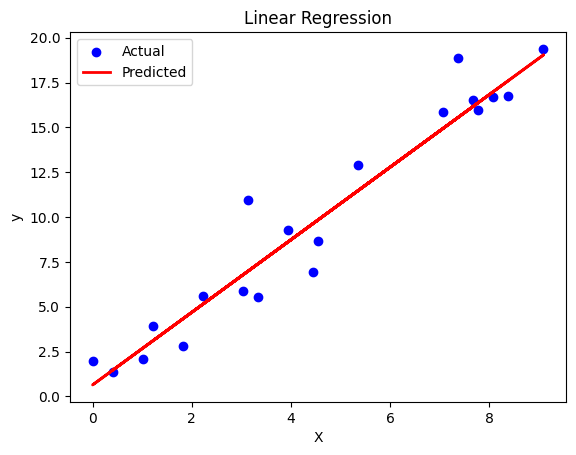

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate sample data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print results
print(f"Coefficient: {model.coef_[0][0]:.2f}")
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

# Visualize
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression')
plt.show()




Example 1.1. Spam Detection - Naive Bayes Model Variants.ipynb


Test Email: Free Prize waiting for you. Signup Free Now!
MultinomialNB → SPAM | Prob(Spam)=0.91
BernoulliNB   → SPAM | Prob(Spam)=0.96
GaussianNB    → SPAM | Prob(Spam)=1.0


/tmp/ipykernel_142/4255374684.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["MultinomialNB", "BernoulliNB", "GaussianNB"],


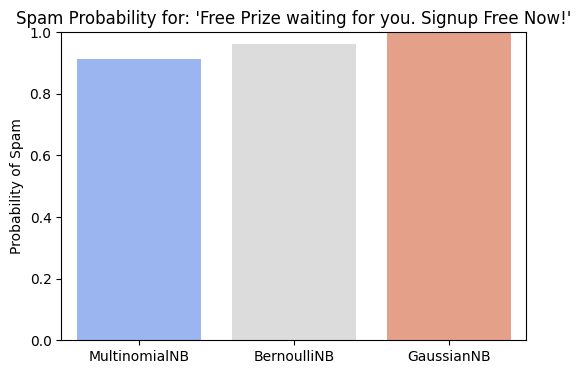

In [ ]:
# ================================
# Step 1: Install & Import Libraries
# ================================
!pip install scikit-learn seaborn matplotlib
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
import seaborn as sns
import matplotlib.pyplot as plt
# ================================
# Step 2: Sample Email Dataset
# ================================
emails = [
   "Win a Free iPhone now",        # Spam
   "Congratulations you won cash", # Spam
   "Free entry to win a prize",    # Spam
   "Meeting schedule for tomorrow",# Not Spam
   "Let's have lunch next week",   # Not Spam
   "Project report submission"     # Not Spam
]
labels = [1, 1, 1, 0, 0, 0]  # 1 = Spam, 0 = Not Spam
# Convert text to numerical features
vectorizer = CountVectorizer(binary=True)  # binary=True for BernoulliNB compatibility
X = vectorizer.fit_transform(emails)
# ================================
# Step 3: Define Test Email
# ================================
test_email = ["Free Prize waiting for you. Signup Free Now!"]
X_test = vectorizer.transform(test_email)
# ================================
# Step 4: Train & Predict - MultinomialNB
# ================================
multi_nb = MultinomialNB()
multi_nb.fit(X, labels)
multi_pred = multi_nb.predict(X_test)[0]
multi_prob = multi_nb.predict_proba(X_test)[0]
# ================================
# Step 5: Train & Predict - BernoulliNB
# ================================
bern_nb = BernoulliNB()
bern_nb.fit(X, labels)
bern_pred = bern_nb.predict(X_test)[0]
bern_prob = bern_nb.predict_proba(X_test)[0]
# ================================
# Step 6: Train & Predict - GaussianNB
# (Needs dense array instead of sparse matrix)
# ================================
gauss_nb = GaussianNB()
gauss_nb.fit(X.toarray(), labels)
gauss_pred = gauss_nb.predict(X_test.toarray())[0]
gauss_prob = gauss_nb.predict_proba(X_test.toarray())[0]
# ================================
# Step 7: Print Results
# ================================
print("\nTest Email:", test_email[0])
print(f"MultinomialNB → {'SPAM' if multi_pred==1 else 'NOT SPAM'} | Prob(Spam)={round(multi_prob[1],2)}")
print(f"BernoulliNB   → {'SPAM' if bern_pred==1 else 'NOT SPAM'} | Prob(Spam)={round(bern_prob[1],2)}")
print(f"GaussianNB    → {'SPAM' if gauss_pred==1 else 'NOT SPAM'} | Prob(Spam)={round(gauss_prob[1],2)}")
# ================================
# Step 8: Visualization - Compare Models
# ================================
plt.figure(figsize=(6,4))
sns.barplot(x=["MultinomialNB", "BernoulliNB", "GaussianNB"],
           y=[multi_prob[1], bern_prob[1], gauss_prob[1]],
           palette="coolwarm")
plt.title(f"Spam Probability for: '{test_email[0]}'")
plt.ylabel("Probability of Spam")
plt.ylim(0,1)
plt.show()
#Note: Use MultinomialNB for text (spam detection),
#BernoulliNB for binary presence/absence data, and
#GaussianNB for continuous numeric data.

Example 1.2 Fraud detection.ipynb

Sample Transactions:
        amount  international  suspicious_flag  fraud
0   46.926809              0                0      0
1  301.012143              0                0      0
2  131.674569              0                0      0
3   91.294255              0                0      0
4   16.962487              0                0      0

Classification Report:
              precision    recall  f1-score   support

           0     0.9963    0.9522    0.9738     14905
           1     0.0570    0.4526    0.1012        95

    accuracy                         0.9491     15000
   macro avg     0.5267    0.7024    0.5375     15000
weighted avg     0.9904    0.9491    0.9683     15000

ROC-AUC Score: 0.9123755716026061


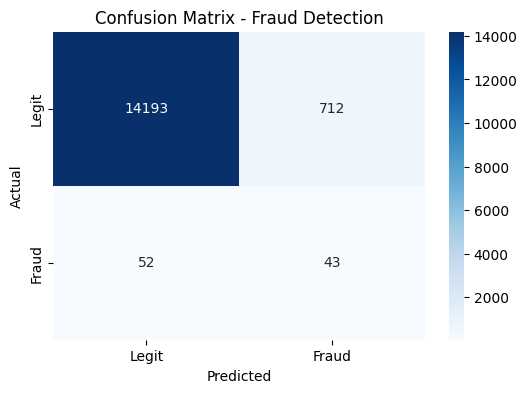

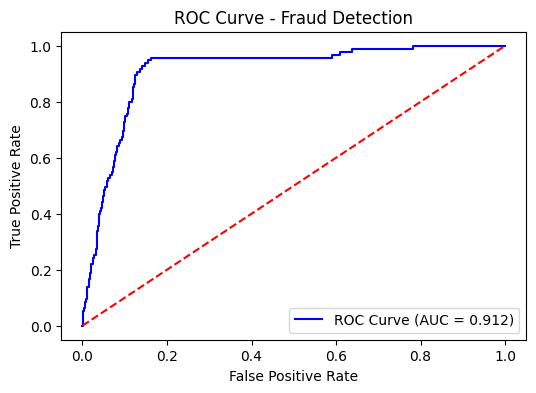

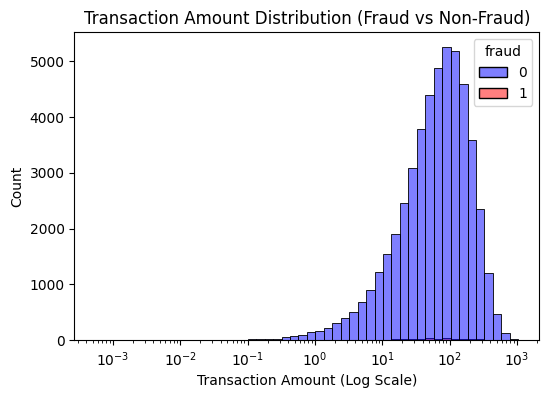

In [ ]:
# Install libraries (only once in Colab)
!pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Step 1: Simulate Transaction Data
np.random.seed(42)
n_samples = 50000

amount = np.random.exponential(scale=100, size=n_samples)
international = np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1])
suspicious_flag = np.random.choice([0, 1], size=n_samples, p=[0.95, 0.05])

fraud = []
for i in range(n_samples):
   prob_fraud = 0.001
   if amount[i] > 500:
       prob_fraud += 0.01
   if international[i] == 1:
       prob_fraud += 0.03
   if suspicious_flag[i] == 1:
       prob_fraud += 0.05
   fraud.append(np.random.rand() < prob_fraud)

fraud = np.array(fraud, dtype=int)
df = pd.DataFrame({
   "amount": amount,
   "international": international,
   "suspicious_flag": suspicious_flag,
   "fraud": fraud
})

print("Sample Transactions:\n", df.head())

# Step 2: Train/Test Split
X = df.drop("fraud", axis=1)
y = df["fraud"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 3: Train Model
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

# Step 4: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fraud Detection")
plt.show()

# Step 5: ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.show()

'''
The ROC Curve is a graphical tool used to evaluate the performance of a binary classification model
(e.g., spam vs. not spam, fraud vs. genuine transaction).

Ideal Model: Curve hugs the top-left corner → High TPR, Low FPR.
Random Guessing: Diagonal line (45°) from (0,0) to (1,1).
Worse than Random: Curve falls below the diagonal.

The AUC measures overall model performance:
1.0 → Perfect model
0.5 → Random guessing
<0.5 → Worse than random

'''

# Step 6: Fraud vs Non-Fraud Transaction Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="amount", hue="fraud", bins=50, palette={0: "blue", 1: "red"}, log_scale=True)
plt.title("Transaction Amount Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Transaction Amount (Log Scale)")
plt.show()




Example 1.3 K-NN Regression (House Price Prediction).ipynb

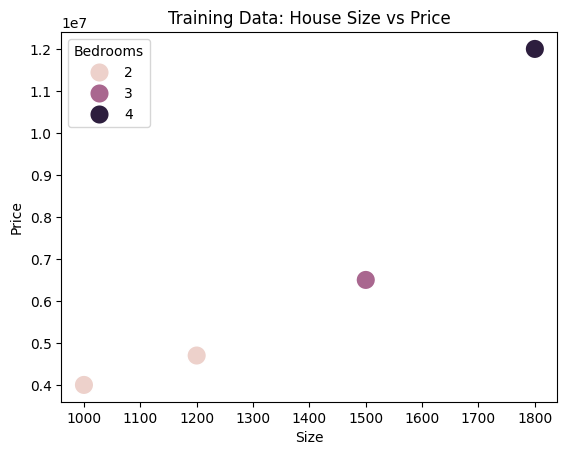

Predicting price of 1400 sqf with 3 bedrooms -
Predicted Price: $5,600,000.00


In [ ]:
#K-NN Regression (House Price Prediction)

from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Training Data
X_train = np.array([[1000, 2], [1500, 3], [1200, 2], [1800, 4]])
y_train = np.array([4000000, 6500000, 4700000, 12000000])

# Create DataFrame
df = pd.DataFrame(X_train, columns=['Size', 'Bedrooms'])
df['Price'] = y_train

# Plot all data points
sns.scatterplot(data=df, x='Size', y='Price', hue='Bedrooms', s=200)
plt.title('Training Data: House Size vs Price')
plt.show()

# K-NN Model
knn_reg = KNeighborsRegressor(n_neighbors=2)
knn_reg.fit(X_train, y_train)

# Predict
print("Predicting price of 1400 sqf with 3 bedrooms -")
new_house = np.array([[1400, 3]])
predicted_price = knn_reg.predict(new_house)
print(f"Predicted Price: ${predicted_price[0]:,.2f}")


Example 2 Image Classification.ipynb

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9052 - loss: 0.3262 - val_accuracy: 0.9569 - val_loss: 0.1517
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9540 - loss: 0.1563 - val_accuracy: 0.9671 - val_loss: 0.1139
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9650 - loss: 0.1168 - val_accuracy: 0.9723 - val_loss: 0.0934
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9715 - loss: 0.0947 - val_accuracy: 0.9722 - val_loss: 0.0917
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9756 - loss: 0.0807 - val_accuracy: 0.9747 - val_loss: 0.0841
Test accuracy: 0.9746
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


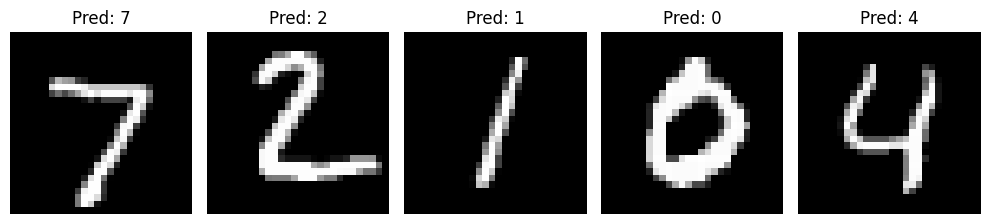

In [ ]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build a simple neural network
model = tf.keras.Sequential([
   tf.keras.layers.Flatten(input_shape=(28, 28)),
   tf.keras.layers.Dense(128, activation='relu'),
   tf.keras.layers.Dropout(0.2),
   tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions on a few test images
predictions = model.predict(x_test[:5])

# Display some predictions
plt.figure(figsize=(10, 5))
for i in range(5):
   plt.subplot(1, 5, i+1)
   plt.imshow(x_test[i], cmap='gray')
   plt.title(f"Pred: {np.argmax(predictions[i])}")
   plt.axis('off')
plt.tight_layout()
plt.show()




Example 4 Sentiment Analysis with Simple RNN.ipynb

In [ ]:
# Import libraries

import tensorflow as tf

import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample data

sentences = [

    'I love this movie',

    'This film is amazing',

    'Great acting and story',

    'Terrible movie, waste of time',

    'I hated this film',

    'Boring and predictable',

    'Best movie ever',

    'Not good at all',

    'Absolutely fantastic',

    'Poor acting and script'

]

# Labels: 1 for positive, 0 for negative

labels = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]

# Tokenize the text

tokenizer = Tokenizer(num_words=100, oov_token='<OOV>')

tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index

# Convert to sequences and pad

sequences = tokenizer.texts_to_sequences(sentences)

padded = pad_sequences(sequences, maxlen=5, padding='post')

# Build a simple RNN model

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(100, 16, input_length=5),

    tf.keras.layers.SimpleRNN(32),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model

history = model.fit(padded, np.array(labels), epochs=50, verbose=0)

# Test on new sentences

test_sentences = [

    'This is amazing',

    'What a terrible film',

    'I love it'

]

test_sequences = tokenizer.texts_to_sequences(test_sentences)

test_padded = pad_sequences(test_sequences, maxlen=5, padding='post')

predictions = model.predict(test_padded)

for i, sentence in enumerate(test_sentences):

    sentiment = "Positive" if predictions[i] > 0.5 else "Negative"

    print(f"'{sentence}' -> {sentiment} (confidence: {predictions[i][0]:.2f})")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
'This is amazing' -> Positive (confidence: 0.72)
'What a terrible film' -> Negative (confidence: 0.46)
'I love it' -> Positive (confidence: 0.71)


Example 8 Decision Tree Classifier.ipynb

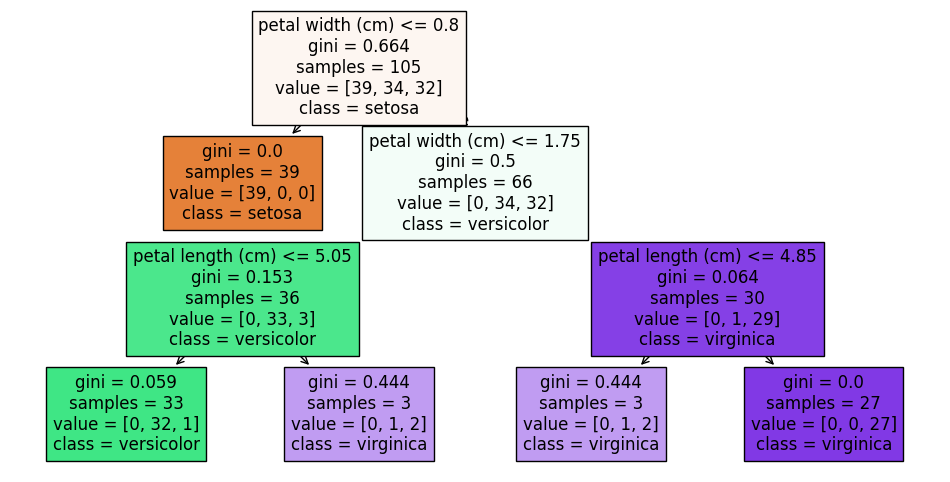

Accuracy: 0.98


In [ ]:
# Simple Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Load data and train

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3)

# Simple tree (depth=3)

tree = DecisionTreeClassifier(max_depth=3)

tree.fit(X_train, y_train)

# See the tree

plt.figure(figsize=(12,6))

plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)

plt.show()

# Check accuracy

print(f"Accuracy: {tree.score(X_test, y_test):.2f}")


Example 10 Time Series Forecasting with ARIMA.ipynb

ADF Statistic: -0.7630957713369958
p-value: 0.8297228394002242
Critical Values:
	1%: -3.466398230774071
	5%: -2.8773796387256514
	10%: -2.575213838610586
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  150
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -364.457
Date:                Fri, 13 Mar 2026   AIC                            740.915
Time:                        06:35:51   BIC                            758.938
Sample:                             0   HQIC                           748.237
                                - 150                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3027      0.083     -3.656      0.000  

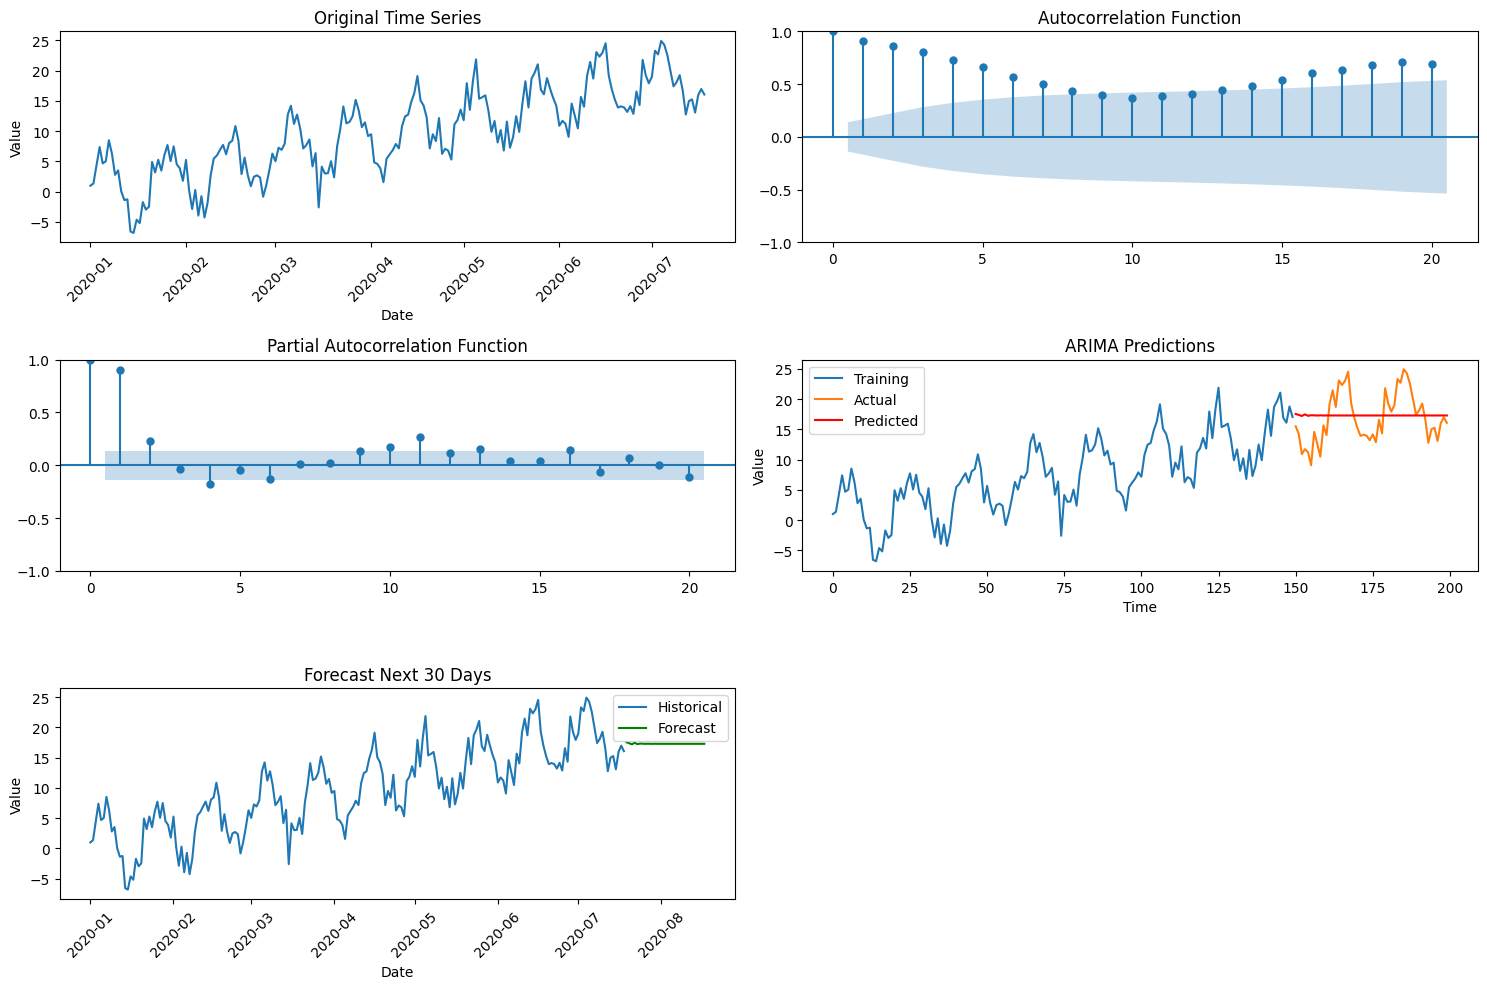

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Generate sample time series data
np.random.seed(42)
time = np.arange(0, 200)
trend = 0.1 * time
seasonal = 5 * np.sin(2 * np.pi * time / 20)
noise = np.random.normal(0, 2, 200)
data = trend + seasonal + noise

# Create a DataFrame
df = pd.DataFrame({'date': pd.date_range(start='2020-01-01', periods=200, freq='D'),
                  'value': data})

# Plot the time series
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.plot(df['date'], df['value'])
plt.title('Original Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)

# Check stationarity with ADF test
result = adfuller(df['value'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
   print(f'\t{key}: {value}')

# Plot ACF and PACF
plt.subplot(3, 2, 2)
plot_acf(df['value'], lags=20, ax=plt.gca())
plt.title('Autocorrelation Function')

plt.subplot(3, 2, 3)
plot_pacf(df['value'], lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function')

# Split data into train and test
train = df['value'][:150]
test = df['value'][150:]

# Fit ARIMA model
model = ARIMA(train, order=(5,1,0))  # (p,d,q) parameters
fitted_model = model.fit()

# Print model summary
print(fitted_model.summary())

# Make predictions
predictions = fitted_model.forecast(steps=len(test))

# Plot predictions vs actual
plt.subplot(3, 2, 4)
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted', color='red')
plt.title('ARIMA Predictions')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()

# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

# Forecast future values
future_steps = 30
future_forecast = fitted_model.forecast(steps=future_steps)
future_dates = pd.date_range(start=df['date'].iloc[-1] + pd.Timedelta(days=1),
                           periods=future_steps, freq='D')

plt.subplot(3, 2, 5)
plt.plot(df['date'], df['value'], label='Historical')
plt.plot(future_dates, future_forecast, label='Forecast', color='green')
plt.title(f'Forecast Next {future_steps} Days')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()




Example 16 Simple CNN for Image Classification.ipynb

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


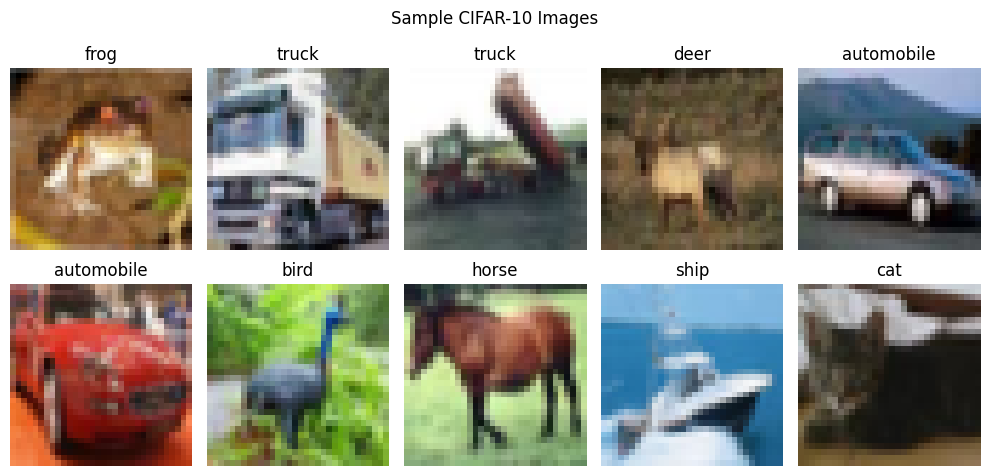

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.3538 - loss: 1.7450 - val_accuracy: 0.4969 - val_loss: 1.4765
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.4804 - loss: 1.4290 - val_accuracy: 0.5666 - val_loss: 1.1901
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 90ms/step - accuracy: 0.5371 - loss: 1.2857 - val_accuracy: 0.6144 - val_loss: 1.1175
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.5781 - loss: 1.1852 - val_accuracy: 0.6447 - val_loss: 0.9992
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.6137 - loss: 1.0862 - val_accuracy: 0.6720 - val_loss: 0.9350
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6422 - loss: 1.0119 - val_accuracy: 0.6920 - val_loss: 0.9079
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.6630 - loss: 0.9575 - val_accuracy: 0.7092 - val_loss: 0.8486
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.6802 - loss: 0.9017 - 

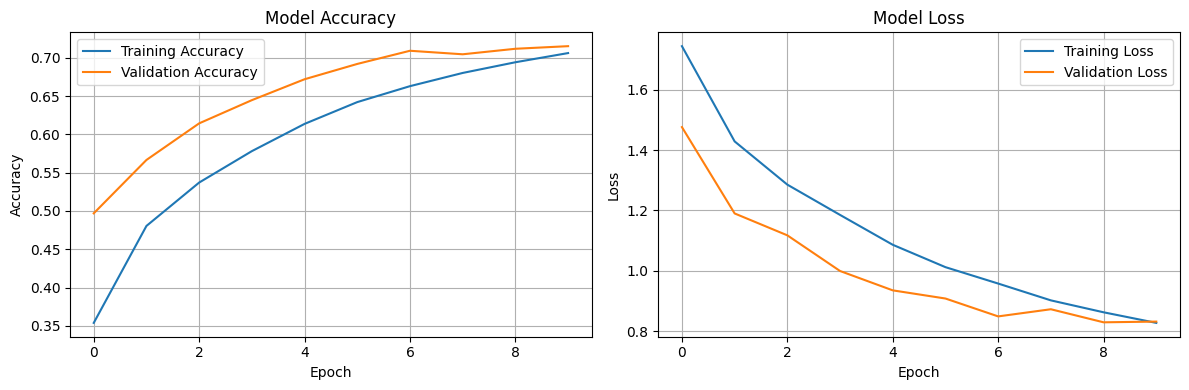

Test accuracy: 0.7152
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


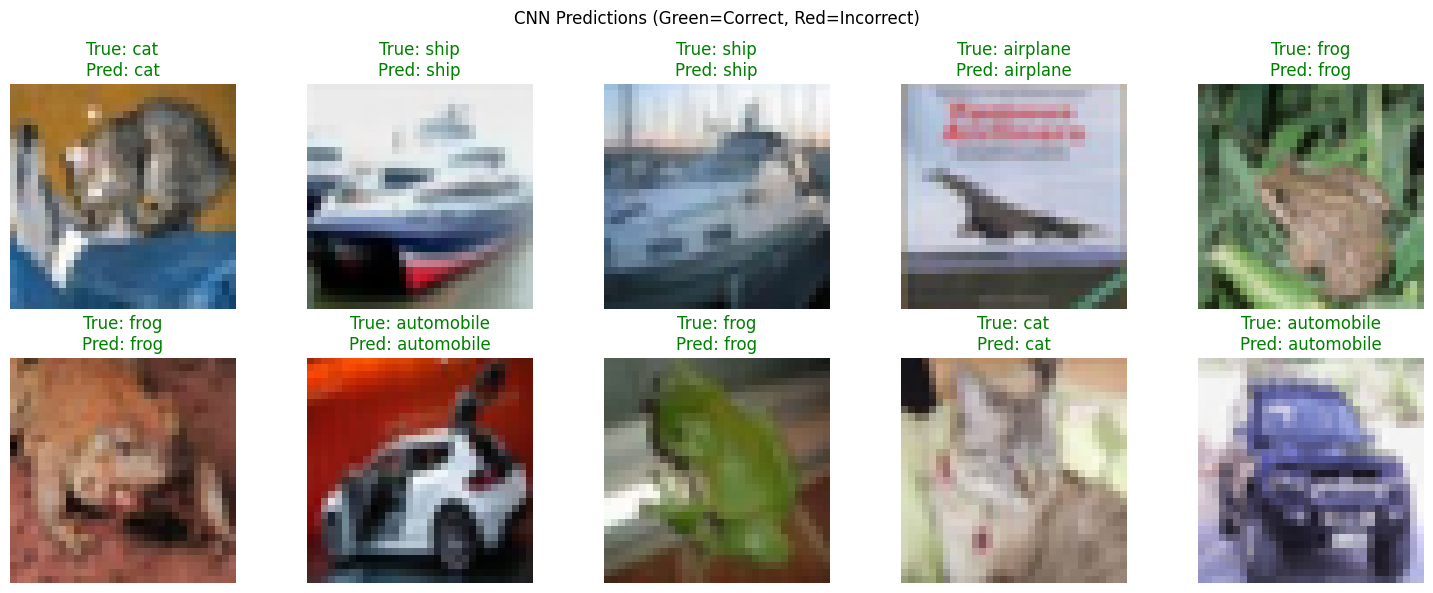

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


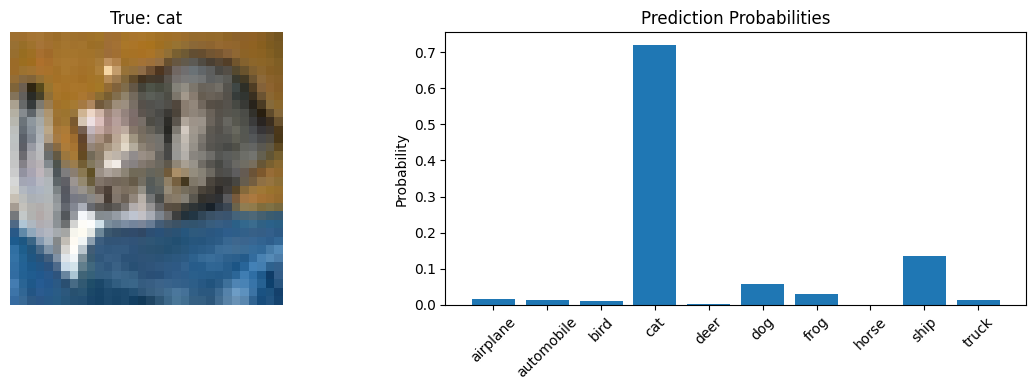


Prediction for this image:
airplane: 0.0156
automobile: 0.0149
bird: 0.0109
cat: 0.7190
deer: 0.0035
dog: 0.0567
frog: 0.0313
horse: 0.0006
ship: 0.1349
truck: 0.0127
Predicted class: cat


In [ ]:
# Import libraries

import tensorflow as tf

from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

import numpy as np

# Load and prepare the CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]

x_train = x_train.astype('float32') / 255.0

x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)

y_train = tf.keras.utils.to_categorical(y_train, 10)

y_test = tf.keras.utils.to_categorical(y_test, 10)

# Class names for CIFAR-10

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',

               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data shape: {x_train.shape}")

print(f"Test data shape: {x_test.shape}")

print(f"Number of classes: {len(class_names)}")

# Display some sample images

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[np.argmax(y_train[i])])

    plt.axis('off')

plt.suptitle('Sample CIFAR-10 Images')

plt.tight_layout()

plt.show()

# Build a simple CNN model

def create_simple_cnn():

    model = models.Sequential([

        # First convolutional layer

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),

        layers.MaxPooling2D((2, 2)),

        # Second convolutional layer

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

        layers.MaxPooling2D((2, 2)),

        # Third convolutional layer

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

        # Flatten and dense layers

        layers.Flatten(),

        layers.Dense(64, activation='relu'),

        layers.Dropout(0.5),  # Prevent overfitting

        layers.Dense(10, activation='softmax')

    ])

    return model

# Create the model

model = create_simple_cnn()

# Display model architecture

model.summary()

# Compile the model

model.compile(optimizer='adam',

              loss='categorical_crossentropy',

              metrics=['accuracy'])

# Train the model

history = model.fit(x_train, y_train,

                    batch_size=64,

                    epochs=10,

                    validation_data=(x_test, y_test),

                    verbose=1)

# Plot training history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Model Accuracy')

plt.legend()

plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Model Loss')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# Evaluate on test set

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy: {test_acc:.4f}")

# Make predictions on test images

predictions = model.predict(x_test[:10])

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test[:10], axis=1)

# Display predictions

plt.figure(figsize=(15, 6))

for i in range(10):

    plt.subplot(2, 5, i+1)

    plt.imshow(x_test[i])

    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'

    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}",

              color=color)

    plt.axis('off')

plt.suptitle('CNN Predictions (Green=Correct, Red=Incorrect)')

plt.tight_layout()

plt.show()

# Show prediction probabilities for a single image

sample_idx = 0

sample_image = x_test[sample_idx:sample_idx+1]

sample_pred = model.predict(sample_image)[0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.imshow(x_test[sample_idx])

plt.title(f"True: {class_names[true_classes[sample_idx]]}")

plt.axis('off')

plt.subplot(1, 2, 2)

plt.bar(class_names, sample_pred)

plt.title("Prediction Probabilities")

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.tight_layout()

plt.show()

print(f"\nPrediction for this image:")

for i, (class_name, prob) in enumerate(zip(class_names, sample_pred)):

    print(f"{class_name}: {prob:.4f}")

print(f"Predicted class: {class_names[np.argmax(sample_pred)]}")


Example 17 CNN with Data Augmentation.ipynb

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


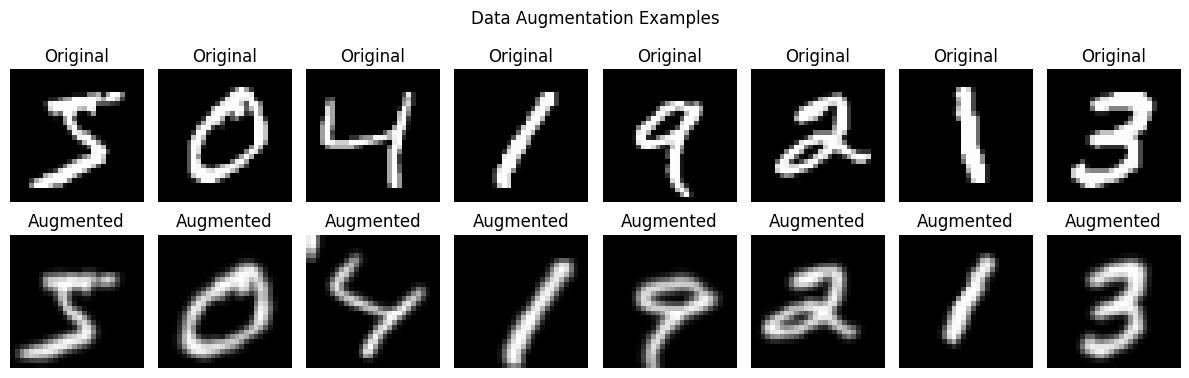

Training model WITHOUT data augmentation...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.8894 - loss: 0.4103 - val_accuracy: 0.2018 - val_loss: 3.7208
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 166ms/step - accuracy: 0.9758 - loss: 0.0909 - val_accuracy: 0.9758 - val_loss: 0.0759
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 164ms/step - accuracy: 0.9815 - loss: 0.0674 - val_accuracy: 0.9864 - val_loss: 0.0436
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 157ms/step - accuracy: 0.9862 - loss: 0.0521 - val_accuracy: 0.9842 - val_loss: 0.0456
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 162ms/step - accuracy: 0.9882 - loss: 0.0431 - val_accuracy: 0.9739 - val_loss: 0.0837

Training model WITH data augmentation...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 183ms/step - accuracy: 0.8224 - loss: 0.6045 - val_accuracy: 0.5211 - val_loss: 1.3669
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.9543 - loss: 0.1676 - val_accuracy: 0.8639 - val_loss: 0.4737
Epoc

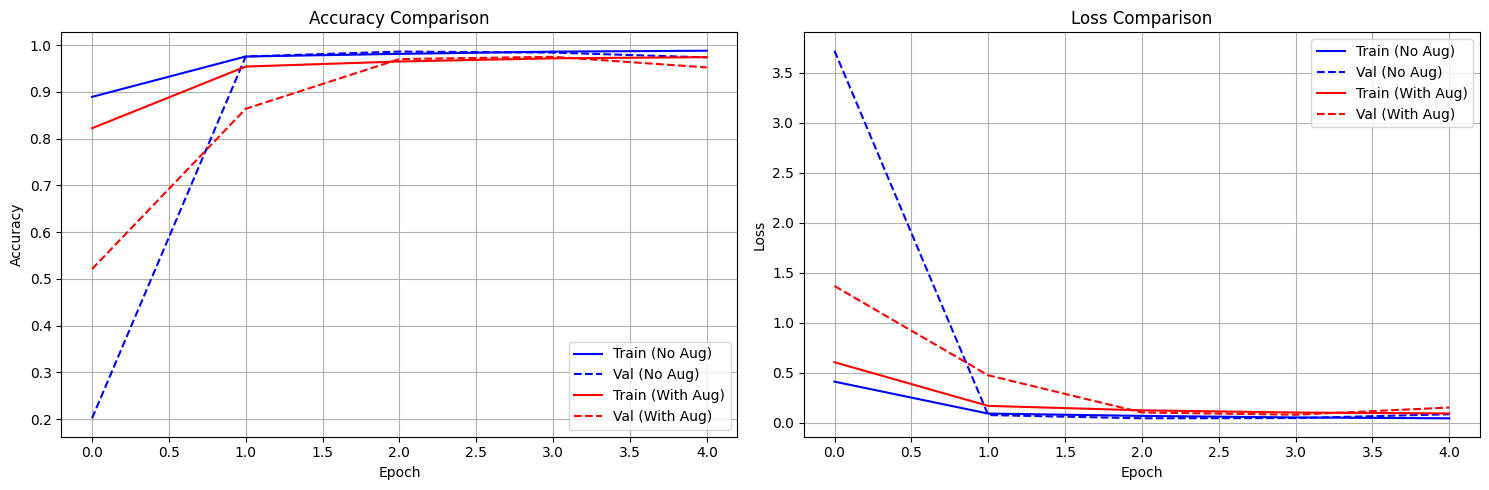


Model without augmentation - Test accuracy: 0.9739
Model with augmentation - Test accuracy: 0.9525


In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset (simpler than CIFAR-10)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Create data augmentation layer
data_augmentation = tf.keras.Sequential([
   layers.RandomRotation(0.1),
   layers.RandomZoom(0.1),
   layers.RandomTranslation(0.1, 0.1),
])

# Visualize augmented images
plt.figure(figsize=(12, 4))
for i in range(8):
   # Original image
   plt.subplot(2, 8, i+1)
   plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
   plt.title('Original')
   plt.axis('off')

   # Augmented image
   augmented = data_augmentation(x_train[i:i+1])
   plt.subplot(2, 8, i+9)
   plt.imshow(augmented[0].numpy().reshape(28, 28), cmap='gray')
   plt.title('Augmented')
   plt.axis('off')
plt.suptitle('Data Augmentation Examples')
plt.tight_layout()
plt.show()

# Build CNN model for MNIST
def create_mnist_cnn():
   model = models.Sequential([
       # First convolutional block
       layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
       layers.BatchNormalization(),
       layers.MaxPooling2D((2, 2)),

       # Second convolutional block
       layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
       layers.BatchNormalization(),
       layers.MaxPooling2D((2, 2)),

       # Third convolutional block
       layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
       layers.BatchNormalization(),

       # Global average pooling instead of flatten
       layers.GlobalAveragePooling2D(),

       # Dense layers
       layers.Dense(64, activation='relu'),
       layers.Dropout(0.5),
       layers.Dense(10, activation='softmax')
   ])
   return model

# Create model with data augmentation in the pipeline
model_with_augmentation = models.Sequential([
   layers.Input(shape=(28, 28, 1)),
   data_augmentation,
   create_mnist_cnn()
])

# Create model without augmentation for comparison
model_without_augmentation = create_mnist_cnn()

# Compile both models
model_with_augmentation.compile(optimizer='adam',
                               loss='categorical_crossentropy',
                               metrics=['accuracy'])

model_without_augmentation.compile(optimizer='adam',
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])

# Train model without augmentation
print("Training model WITHOUT data augmentation...")
history_without = model_without_augmentation.fit(
   x_train, y_train,
   batch_size=128,
   epochs=5,
   validation_data=(x_test, y_test),
   verbose=1
)

# Train model with augmentation
print("\nTraining model WITH data augmentation...")
history_with = model_with_augmentation.fit(
   x_train, y_train,
   batch_size=128,
   epochs=5,
   validation_data=(x_test, y_test),
   verbose=1
)

# Compare results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history_without.history['accuracy'], 'b-', label='Train (No Aug)')
plt.plot(history_without.history['val_accuracy'], 'b--', label='Val (No Aug)')
plt.plot(history_with.history['accuracy'], 'r-', label='Train (With Aug)')
plt.plot(history_with.history['val_accuracy'], 'r--', label='Val (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_without.history['loss'], 'b-', label='Train (No Aug)')
plt.plot(history_without.history['val_loss'], 'b--', label='Val (No Aug)')
plt.plot(history_with.history['loss'], 'r-', label='Train (With Aug)')
plt.plot(history_with.history['val_loss'], 'r--', label='Val (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate both models
test_loss_no_aug, test_acc_no_aug = model_without_augmentation.evaluate(x_test, y_test, verbose=0)
test_loss_aug, test_acc_aug = model_with_augmentation.evaluate(x_test, y_test, verbose=0)

print(f"\nModel without augmentation - Test accuracy: {test_acc_no_aug:.4f}")
print(f"Model with augmentation - Test accuracy: {test_acc_aug:.4f}")




Example 19 ANN example on Fashion MNIST dataset.ipynb

TensorFlow version: 2.19.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10


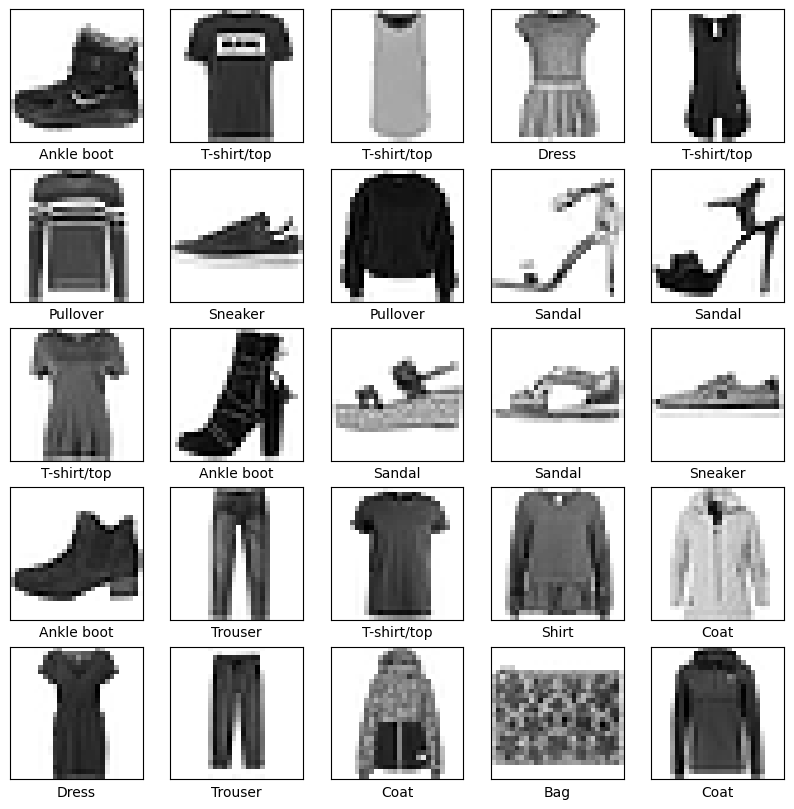

Training images shape after reshaping: (60000, 784)
Test images shape after reshaping: (10000, 784)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8178 - loss: 0.5155 - val_accuracy: 0.8376 - val_loss: 0.4474
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8618 - loss: 0.3801 - val_accuracy: 0.8511 - val_loss: 0.3956
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8753 - loss: 0.3402 - val_accuracy: 0.8745 - val_loss: 0.3481
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8823 - loss: 0.3185 - val_accuracy: 0.8775 - val_loss: 0.3379
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8899 - loss: 0.2963 - val_accuracy: 0.8754 - val_loss: 0.3450
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8954 - loss: 0.2812 - val_accuracy: 0.8809 - val_loss: 0.3309
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9001 - loss: 0.2707 - val_accuracy: 0.8832 - val_loss: 0.3367
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9032 - loss: 0.2579 - 

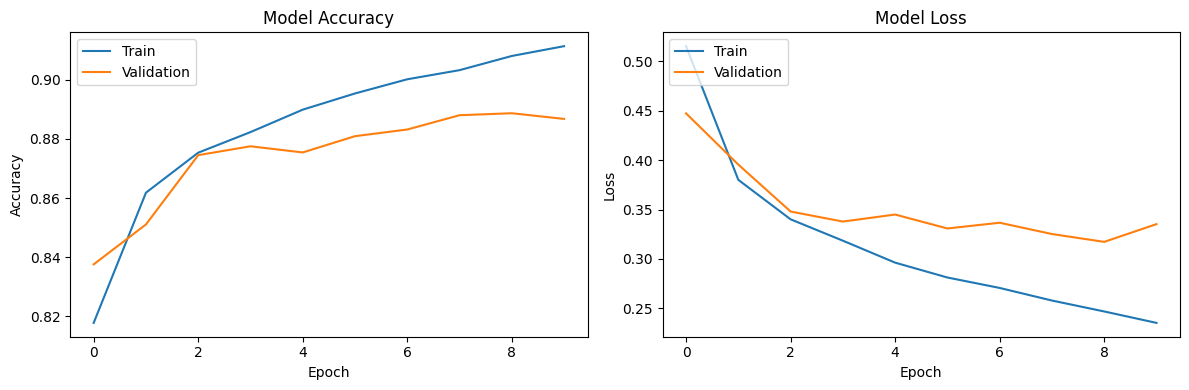

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


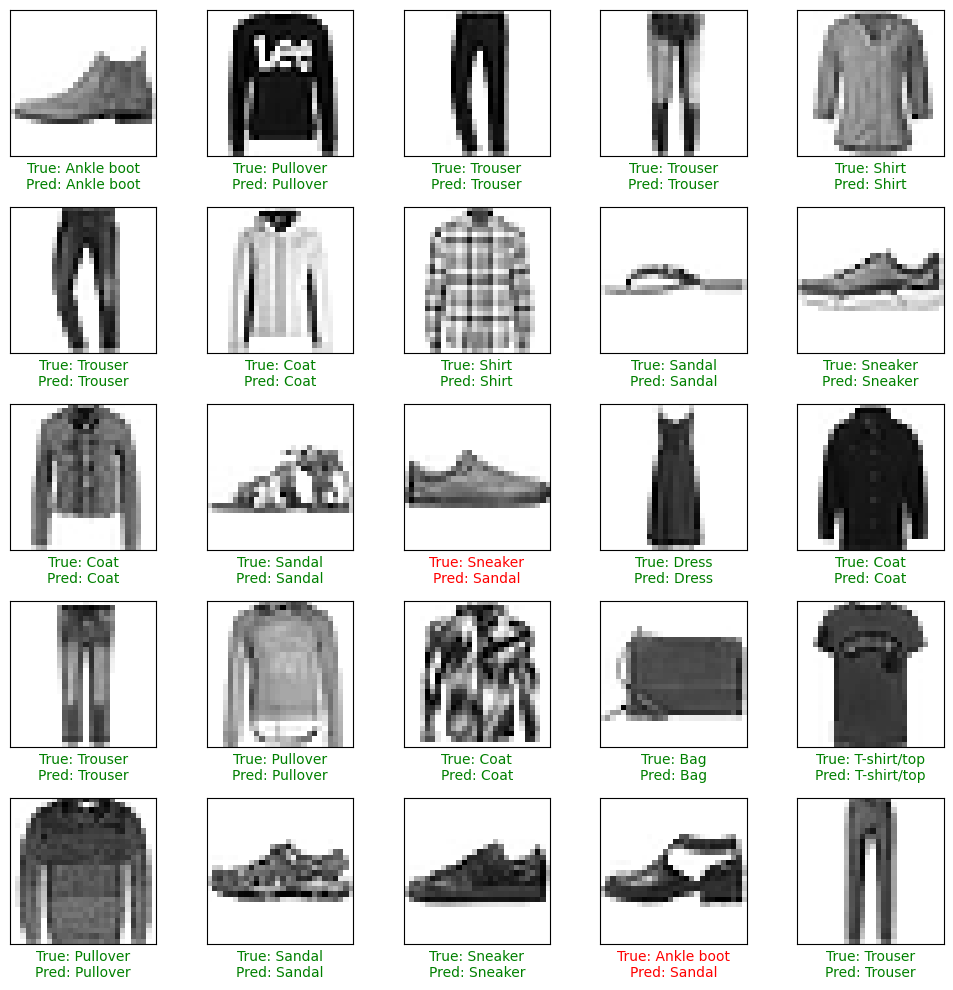

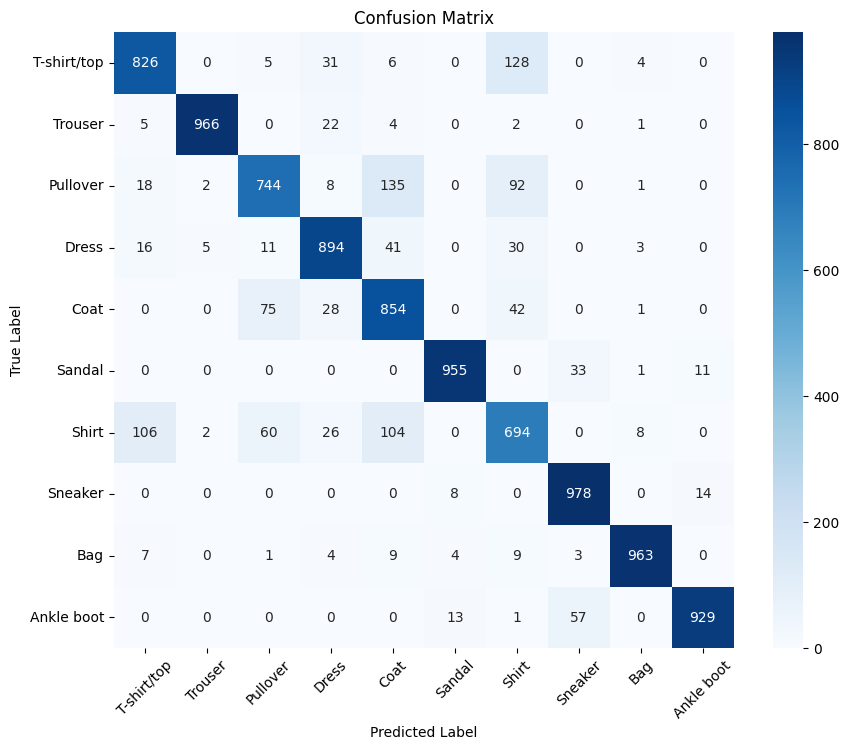

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.83      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.74      0.78      1000
       Dress       0.88      0.89      0.89      1000
        Coat       0.74      0.85      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.70      0.69      0.69      1000
     Sneaker       0.91      0.98      0.94      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.97      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7911 - loss: 0.5734 - val_accuracy: 0.8408 - val_loss: 0.4327
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8436 - loss: 0.4271 - val_accuracy: 0.8477 - val_loss: 0.4045
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8558 - loss: 0.3886 - val_accuracy: 0.8710 - val_loss: 0.3548
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8643 - loss: 0.3673 - val_accuracy: 0.8680 - val_loss: 0.3656
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8698 - loss: 0.3502 - val_accuracy: 0.8721 - val_loss: 0.3391
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8765 - loss: 0.3368 - val_accuracy: 0.8807 - val_loss: 0.3230
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8802 - loss: 0.3237 - val_accuracy: 0.8789 - val_loss: 0.3386
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8823 - loss: 0.3155

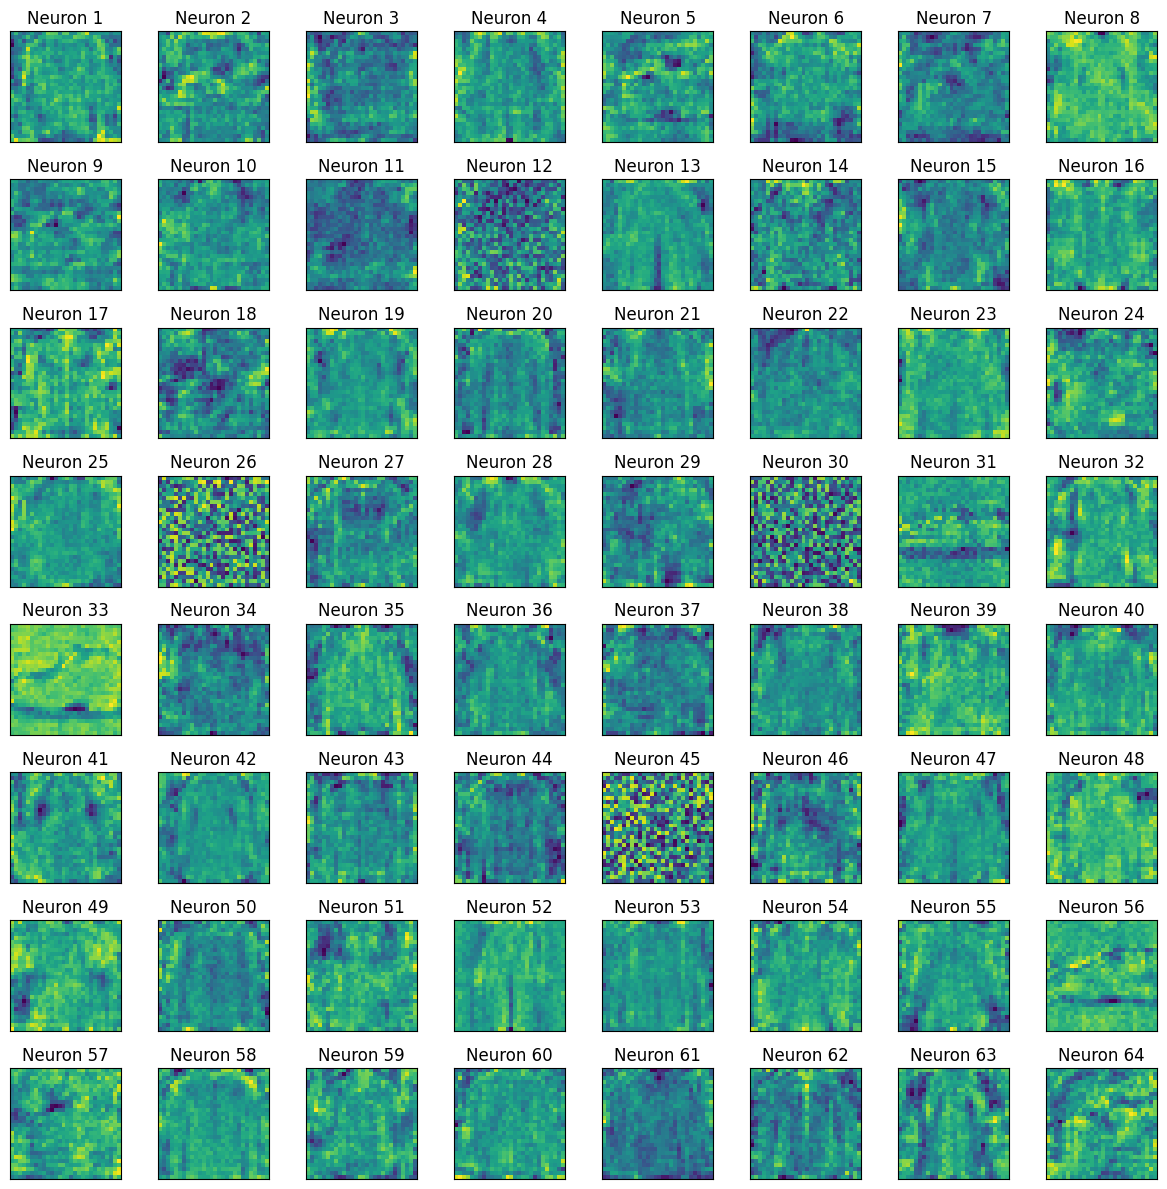

Model saved successfully!
313/313 - 2s - 5ms/step - accuracy: 0.8803 - loss: 0.3587

Loaded model test accuracy: 0.8803
Loaded model test loss: 0.3587
FINAL PERFORMANCE METRICS
Original Model Test Accuracy: 0.8803
Deeper Model Test Accuracy: 0.8827
Improvement: 0.24%


In [ ]:
# Import necessary libraries

import tensorflow as tf

from tensorflow import keras

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Check TensorFlow version

print("TensorFlow version:", tf.__version__)

"""## 1. Load and Explore the Dataset

Fashion MNIST is a dataset of Zalando's article images—consisting of 70,000 grayscale images in 10 categories.

"""

# Load the Fashion MNIST dataset

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Class names for Fashion MNIST

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',

               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Explore the dataset

print("Training images shape:", train_images.shape)

print("Training labels shape:", train_labels.shape)

print("Test images shape:", test_images.shape)

print("Test labels shape:", test_labels.shape)

print("Number of classes:", len(class_names))

# Display a sample of the images

plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])

    plt.yticks([])

    plt.grid(False)

    plt.imshow(train_images[i], cmap=plt.cm.binary)

    plt.xlabel(class_names[train_labels[i]])

plt.show()

"""## 2. Preprocess the Data

Neural networks work better with normalized data. We'll scale the pixel values to a range of 0 to 1.

"""

# Normalize pixel values to be between 0 and 1

train_images = train_images / 255.0

test_images = test_images / 255.0

# Reshape the data for the neural network (flatten the 28x28 images to 784 pixels)

train_images = train_images.reshape(train_images.shape[0], 28*28)

test_images = test_images.reshape(test_images.shape[0], 28*28)

print("Training images shape after reshaping:", train_images.shape)

print("Test images shape after reshaping:", test_images.shape)

"""## 3. Build the Artificial Neural Network

We'll create a feedforward neural network with:

- Input layer: 784 neurons (28x28 pixels)

- Hidden layers: Two hidden layers with 128 and 64 neurons respectively

- Output layer: 10 neurons (one for each class)

"""

# Build the model

model = keras.Sequential([

    keras.layers.Dense(128, activation='relu', input_shape=(784,)),  # Input layer + first hidden layer

    keras.layers.Dense(64, activation='relu'),                       # Second hidden layer

    keras.layers.Dense(10, activation='softmax')                     # Output layer

])

# Compile the model

model.compile(optimizer='adam',

              loss='sparse_categorical_crossentropy',

              metrics=['accuracy'])

# Display the model architecture

model.summary()

"""## 4. Train the Neural Network

Now we'll train the model using the training data.

"""

# Train the model

history = model.fit(train_images, train_labels,

                    epochs=10,

                    batch_size=32,

                    validation_split=0.2)  # Use 20% of training data for validation

"""## 5. Evaluate the Model

Let's see how well the model performs on the test dataset.

"""

# Evaluate the model on test data

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print(f'\nTest accuracy: {test_acc:.4f}')

print(f'Test loss: {test_loss:.4f}')

# Plot training history

plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values

plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values

plt.subplot(1, 2, 2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()

plt.show()

"""## 6. Make Predictions

Let's use the trained model to make predictions on the test data.

"""

# Make predictions

predictions = model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)

# Display some predictions with their true labels

plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])

    plt.yticks([])

    plt.grid(False)

    plt.imshow(test_images[i].reshape(28,28), cmap=plt.cm.binary)

    # Color code the predictions: green for correct, red for incorrect

    if predicted_labels[i] == test_labels[i]:

        color = 'green'

    else:

        color = 'red'

    plt.xlabel(f"True: {class_names[test_labels[i]]}\nPred: {class_names[predicted_labels[i]]}", color=color)

plt.tight_layout()

plt.show()

# Generate a confusion matrix

cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')

plt.ylabel('True Label')

plt.xlabel('Predicted Label')

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

# Classification report

print("Classification Report:")

print(classification_report(test_labels, predicted_labels, target_names=class_names))

"""## 7. Experiment with Different Architectures

Let's try a different architecture to see if we can improve performance.

"""

# Build a deeper model

deeper_model = keras.Sequential([

    keras.layers.Dense(256, activation='relu', input_shape=(784,)),

    keras.layers.Dropout(0.2),  # Add dropout for regularization

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dropout(0.2),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')

])

# Compile the model

deeper_model.compile(optimizer='adam',

                     loss='sparse_categorical_crossentropy',

                     metrics=['accuracy'])

# Display the model architecture

deeper_model.summary()

# Train the deeper model

deeper_history = deeper_model.fit(train_images, train_labels,

                                  epochs=15,

                                  batch_size=32,

                                  validation_split=0.2)

# Evaluate the deeper model

deeper_test_loss, deeper_test_acc = deeper_model.evaluate(test_images, test_labels, verbose=2)

print(f'\nDeeper model test accuracy: {deeper_test_acc:.4f}')

print(f'Deeper model test loss: {deeper_test_loss:.4f}')

# Compare the two models

print(f"Original model test accuracy: {test_acc:.4f}")

print(f"Deeper model test accuracy: {deeper_test_acc:.4f}")

print(f"Improvement: {(deeper_test_acc - test_acc)*100:.2f}%")

"""## 8. Visualize Learned Features

Let's try to visualize what the neural network has learned.

"""

# Get the weights of the first layer

first_layer_weights = model.layers[0].get_weights()[0]

# Visualize the weights

plt.figure(figsize=(12, 12))

for i in range(64):

    plt.subplot(8, 8, i+1)

    plt.xticks([])

    plt.yticks([])

    plt.grid(False)

    # Reshape the weights for visualization

    plt.imshow(first_layer_weights[:, i].reshape(28, 28), cmap='viridis')

    plt.title(f'Neuron {i+1}')

plt.tight_layout()

plt.show()

"""## 9. Save and Load the Model

Once we're satisfied with our model, we can save it for future use.

"""

# Save the model

model.save('fashion_mnist_ann_model.h5')

print("Model saved successfully!")

# Load the model (for demonstration)

loaded_model = keras.models.load_model('fashion_mnist_ann_model.h5')

# Verify the loaded model

loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_images, test_labels, verbose=2)

print(f'\nLoaded model test accuracy: {loaded_test_acc:.4f}')

print(f'Loaded model test loss: {loaded_test_loss:.4f}')

"""## 10. Conclusion

In this notebook, we implemented an Artificial Neural Network to classify fashion items from the Fashion MNIST dataset. We:

1. Loaded and explored the dataset

2. Preprocessed the data for the neural network

3. Built a feedforward neural network with multiple layers

4. Trained and evaluated the model

5. Made predictions and analyzed the results

6. Experimented with a deeper architecture

7. Visualized the learned features

8. Saved and loaded the model

This demonstrates the end-to-end process of building and deploying an ANN for image classification tasks.

- ANNs can effectively learn complex patterns from data

- Proper preprocessing and normalization are important for model performance

- Experimenting with different architectures can improve results

- Regularization techniques like dropout can help prevent overfitting

- Visualization helps understand what the network has learned

"""

# Display final performance metrics

print("FINAL PERFORMANCE METRICS")

print("=" * 50)

print(f"Original Model Test Accuracy: {test_acc:.4f}")

print(f"Deeper Model Test Accuracy: {deeper_test_acc:.4f}")

print(f"Improvement: {(deeper_test_acc - test_acc)*100:.2f}%")
